# ARIA v2.0 - Integrated Impact Auditor (Terrain Intelligence)

## Captain's Log: Week 4 - Terrain Integration
Upgrading Week 3 ARIA system with MOI 20m DEM for comprehensive terrain risk assessment.

**Mission**: Integrate elevation and slope analysis with existing river buffer risk levels.

## Captain's Log: Environment Setup and Package Installation

Ensuring all required packages are installed and imported for ARIA v2.0 terrain intelligence analysis. This cell handles package installation, imports, and environment verification.

In [7]:
# Cell 0: Package Installation and Import Setup

import sys
import subprocess
import importlib

# Required packages for ARIA v2.0
REQUIRED_PACKAGES = [
    'rioxarray',
    'rasterio', 
    'geopandas',
    'matplotlib',
    'numpy',
    'pandas',
    'scipy',
    'requests'
]

print("=== ARIA v2.0 Environment Setup ===")
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

# Install missing packages
print("\n📦 Checking and installing packages...")
for package in REQUIRED_PACKAGES:
    try:
        importlib.import_module(package)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"⬇️ Installing {package}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"✅ {package} installed successfully")
        except subprocess.CalledProcessError as e:
            print(f"❌ Failed to install {package}: {e}")

# Import all required packages
print("\n📚 Importing packages...")
try:
    import rioxarray
    import rasterio
    from rasterio import features
    import geopandas as gpd
    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import scipy
    from scipy import ndimage
    import requests
    import os
    import zipfile
    import io
    import json
    
    print("✅ All packages imported successfully")
    
    # Display package versions
    print("\n=== Package Versions ===")
    print(f"rioxarray: {rioxarray.__version__}")
    print(f"rasterio: {rasterio.__version__}")
    print(f"geopandas: {gpd.__version__}")
    print(f"matplotlib: {matplotlib.__version__}")
    print(f"numpy: {np.__version__}")
    print(f"pandas: {pd.__version__}")
    print(f"scipy: {scipy.__version__}")
    
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Please restart the kernel after package installation")

# Test basic functionality
print("\n🧪 Testing basic functionality...")
try:
    # Test numpy
    test_array = np.array([1, 2, 3])
    print(f"✅ NumPy working: {test_array.mean()}")
    
    # Test pandas
    test_df = pd.DataFrame({'a': [1, 2], 'b': [3, 4]})
    print(f"✅ Pandas working: {len(test_df)} rows")
    
    # Test geopandas
    from shapely.geometry import Point
    test_gdf = gpd.GeoDataFrame({'name': ['test']}, geometry=[Point(0, 0)])
    print(f"✅ GeoPandas working: {len(test_gdf)} geometries")
    
    print("\n🎉 Environment setup complete! Ready for ARIA v2.0 analysis.")
    
except Exception as e:
    print(f"❌ Environment test failed: {e}")

print("\n" + "="*50)
print("ARIA v2.0 - Terrain Intelligence System")
print("Week 4 Assignment: Integrated Impact Auditor")
print("="*50)

=== ARIA v2.0 Environment Setup ===
Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
Python executable: c:\Users\User\anaconda3\envs\geo-risk\python.exe

📦 Checking and installing packages...
✅ rioxarray already installed
✅ rasterio already installed
✅ geopandas already installed
✅ matplotlib already installed
✅ numpy already installed
✅ pandas already installed
✅ scipy already installed
✅ requests already installed

📚 Importing packages...
✅ All packages imported successfully

=== Package Versions ===
rioxarray: 0.19.0
rasterio: 1.4.4
geopandas: 1.1.3
matplotlib: 3.10.8
numpy: 2.4.2
pandas: 3.0.1
scipy: 1.17.1

🧪 Testing basic functionality...
✅ NumPy working: 2.0
✅ Pandas working: 2 rows
✅ GeoPandas working: 1 geometries

🎉 Environment setup complete! Ready for ARIA v2.0 analysis.

ARIA v2.0 - Terrain Intelligence System
Week 4 Assignment: Integrated Impact Auditor


In [ ]:
# Cell 1: Download and Load DEM with rioxarray
import rioxarray
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from rasterio import features
import os
import requests
import zipfile
import io
import pandas as pd
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Configuration from .env file
SLOPE_THRESHOLD = int(os.getenv('SLOPE_THRESHOLD', 30))  # degrees
ELEVATION_LOW = int(os.getenv('ELEVATION_LOW', 50))    # meters
BUFFER_HIGH = int(os.getenv('BUFFER_HIGH', 500))        # meters
TARGET_COUNTY = os.getenv('TARGET_COUNTY', '花蓮縣')    # Hualien County

# Display loaded configuration
print("=== Configuration from .env file ===")
print(f"Slope threshold: {SLOPE_THRESHOLD}°")
print(f"Low elevation: {ELEVATION_LOW}m")
print(f"Buffer distance: {BUFFER_HIGH}m")
print(f"Target county: {TARGET_COUNTY}")

# Google Drive file ID and download URL
file_id = '1y3p9VfAMz-gnCrndozdQAr-7OgWVfjC1'
dem_filename = 'dem_20m_hualien.tif'

# Function to download from Google Drive with proper handling
def download_from_google_drive(file_id, output_path):
    """Download file from Google Drive using the direct download method"""
    
    # First try the direct download method
    download_url = f'https://drive.google.com/uc?export=download&id={file_id}'
    
    try:
        print("📥 Attempting direct download from Google Drive...")
        session = requests.Session()
        
        # Initial request
        response = session.get(download_url, stream=True)
        response.raise_for_status()
        
        # Check for confirmation token (for large files)
        token = get_confirm_token(response)
        
        if token:
            params = {'id': file_id, 'confirm': token}
            response = session.get(download_url, params=params, stream=True)
        
        # Save the file
        with open(output_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=32768):
                if chunk:  # filter out keep-alive new chunks
                    f.write(chunk)
        
        file_size = os.path.getsize(output_path)
        print(f"✅ Downloaded file size: {file_size:,} bytes")
        
        # Check if file size is reasonable for a DEM
        if file_size < 1000000:  # Less than 1MB is probably wrong
            print("⚠️ File seems too small for a DEM, might be an error page")
            return False
            
        return True
        
    except Exception as e:
        print(f"❌ Download failed: {e}")
        return False

def get_confirm_token(response):
    """Get confirmation token for large file downloads"""
    for key, value in response.cookies.items():
        if key.startswith('download_warning'):
            return value
    return None

# Download DEM if not exists
if not os.path.exists(dem_filename):
    success = download_from_google_drive(file_id, dem_filename)
    
    if not success:
        print("❌ Failed to download DEM file")
        print("Please:")
        print("1. Check if the Google Drive link is accessible")
        print("2. Try downloading manually and place the file in this directory")
        print("3. Or update the file_id variable with the correct Google Drive ID")
        dem_filename = None
else:
    print(f"✅ DEM file already exists: {dem_filename}")

# Load DEM with rioxarray
if dem_filename and os.path.exists(dem_filename):
    try:
        print("🔍 Loading DEM with rioxarray...")
        dem = rioxarray.open_rasterio(dem_filename)
        
        # Print DEM information
        print("=== DEM Information ===")
        print(f"File: {dem_filename}")
        print(f"Shape: {dem.shape}")
        print(f"CRS: {dem.rio.crs}")
        print(f"Transform: {dem.rio.transform()}")
        print(f"Resolution: {dem.rio.resolution()}")
        print(f"Bounds: {dem.rio.bounds()}")
        print(f"NoData value: {dem.rio.nodata}")
        
        # Display basic statistics
        print("\n=== Elevation Statistics ===")
        print(f"Min elevation: {float(dem.min()):.2f}m")
        print(f"Max elevation: {float(dem.max()):.2f}m")
        print(f"Mean elevation: {float(dem.mean()):.2f}m")
        
        # Validate DEM data
        if float(dem.max()) < 100:  # Very low max elevation is suspicious
            print("⚠️ Warning: Maximum elevation seems low, please verify DEM data")
        
    except Exception as e:
        print(f"❌ Error loading DEM: {e}")
        print("This might be due to:")
        print("- Corrupted download")
        print("- Unsupported file format")
        print("- Missing dependencies")
        dem = None
else:
    print(f"❌ DEM file not found: {dem_filename}")
    dem = None

# Alternative zonal stats function using rasterio (no rasterstats dependency)
def zonal_stats_vectorto_raster(vectors, raster, stats=['mean', 'max', 'std', 'count']):
    """
    Calculate zonal statistics for vector geometries using rasterio
    
    Parameters:
    vectors: GeoDataFrame with geometries
    raster: xarray DataArray
    stats: list of statistics to calculate
    
    Returns:
    list of dictionaries with statistics for each geometry
    """
    results = []
    
    # Convert raster to numpy array for faster processing
    raster_array = raster.values[0]  # Remove band dimension
    transform = raster.rio.transform()
    nodata = raster.rio.nodata
    
    for geom in vectors.geometry:
        # Create mask for this geometry
        try:
            # Rasterize the geometry
            mask = features.rasterize(
                [(geom, 1)],
                out_shape=raster_array.shape,
                transform=transform,
                fill=0,
                dtype=np.uint8
            )
            
            # Apply mask to raster
            masked_values = raster_array[mask == 1]
            
            # Remove nodata values
            if nodata is not None:
                masked_values = masked_values[masked_values != nodata]
            
            # Calculate statistics
            stats_dict = {}
            if len(masked_values) > 0:
                if 'mean' in stats:
                    stats_dict['mean'] = float(np.mean(masked_values))
                if 'max' in stats:
                    stats_dict['max'] = float(np.max(masked_values))
                if 'min' in stats:
                    stats_dict['min'] = float(np.min(masked_values))
                if 'std' in stats:
                    stats_dict['std'] = float(np.std(masked_values))
                if 'count' in stats:
                    stats_dict['count'] = int(len(masked_values))
            else:
                # No data in this polygon
                for stat in stats:
                    stats_dict[stat] = np.nan
                    
            results.append(stats_dict)
            
        except Exception as e:
            print(f"Warning: Could not process geometry: {e}")
            # Return NaN values for failed geometries
            stats_dict = {stat: np.nan for stat in stats}
            results.append(stats_dict)
    
    return results

print("\n✅ Alternative zonal statistics function ready (no rasterstats dependency)")
print(f"📋 Configuration loaded from .env file")

=== Configuration from .env file ===
Slope threshold: 30°
Low elevation: 50m
Buffer distance: 500m
Target county: 花蓮縣
✅ DEM file already exists: dem_20m_hualien.tif
🔍 Loading DEM with rioxarray...
=== DEM Information ===
File: dem_20m_hualien.tif
Shape: (1, 7054, 3997)
CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Transform: | 20.00, 0.00, 248630.00|
| 0.00,-20.00, 2696210.00|
| 0.00, 0.00, 1.00|
Resolution: (20.0, -20.0)
Bounds: (248630.0, 2555130.0, 328570.0, 2696210.0)
NoData value: -32767.0


In [48]:
# Cell: Compute slope from DEM using np.gradient

import numpy as np
import xarray as xr

if dem is None:
    raise ValueError("❌ dem is None")

# Convert DEM to 2D
dem2d = dem.squeeze(drop=True)

# Convert to numpy array
elev = dem2d.values.astype("float64")

# Handle nodata
nodata = dem2d.rio.nodata
if nodata is not None:
    elev[elev == nodata] = np.nan

# Get DEM resolution
xres, yres = dem2d.rio.resolution()
xres = abs(xres)
yres = abs(yres)

print(f"x resolution = {xres} m")
print(f"y resolution = {yres} m")

# Compute gradients
dz_dy, dz_dx = np.gradient(elev, yres, xres)

# Compute slope in degrees
slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
slope_deg = np.degrees(slope_rad)

# Convert back to DataArray
slope_da = xr.DataArray(
    slope_deg,
    coords=dem2d.coords,
    dims=dem2d.dims,
    name="slope_deg",
    attrs={"units": "degrees", "long_name": "Slope in degrees"}
)

# Keep NaN where DEM is NaN
slope_da = slope_da.where(~np.isnan(dem2d))

print("\n=== Slope Statistics ===")
print(f"Min slope: {float(np.nanmin(slope_da.values)):.2f}°")
print(f"Max slope: {float(np.nanmax(slope_da.values)):.2f}°")
print(f"Mean slope: {float(np.nanmean(slope_da.values)):.2f}°")

x resolution = 20.0 m
y resolution = 20.0 m

=== Slope Statistics ===
Min slope: 0.00°
Max slope: 85.45°
Mean slope: 30.75°


✅ Hillshade created


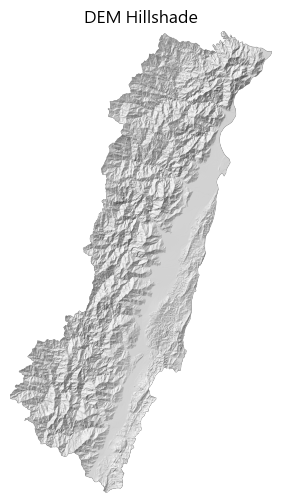

In [49]:
# Cell: Create hillshade from DEM

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

if dem is None:
    raise ValueError("❌ dem is None")

# Convert DEM to 2D
dem2d = dem.squeeze(drop=True)
elev = dem2d.values.astype("float64")

# Handle nodata
nodata = dem2d.rio.nodata
if nodata is not None:
    elev[elev == nodata] = np.nan

# DEM resolution
xres, yres = dem2d.rio.resolution()
xres = abs(xres)
yres = abs(yres)

# Fill NaN temporarily for hillshade calculation
valid_mask = ~np.isnan(elev)
if np.all(~valid_mask):
    raise ValueError("❌ DEM contains no valid values")

fill_value = np.nanmedian(elev[valid_mask])
elev_filled = np.where(valid_mask, elev, fill_value)

# Create hillshade
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elev_filled, vert_exag=1, dx=xres, dy=yres)

# Mask invalid area back to NaN
hillshade = np.where(valid_mask, hillshade, np.nan)

print("✅ Hillshade created")

# Quick preview
plt.figure(figsize=(8, 6))
plt.imshow(hillshade, cmap="gray")
plt.title("DEM Hillshade")
plt.axis("off")
plt.show()

In [50]:
# Cell 4: Load shelter data and create buffer zones

import os
import pandas as pd
import geopandas as gpd
from pyproj import CRS
from dotenv import load_dotenv

# 讀取 .env
load_dotenv()

TARGET_COUNTY = os.getenv("TARGET_COUNTY")
if not TARGET_COUNTY:
    raise ValueError("❌ TARGET_COUNTY not found in .env")

# Use your real file path
shelter_file_path = 'data/shelters/shelters_cleaned_with_river_risk.csv'

if not os.path.exists(shelter_file_path):
    raise FileNotFoundError(f"❌ Shelter file not found: {shelter_file_path}")

print(f"📂 Loading shelter data from: {shelter_file_path}")
shelters_df = pd.read_csv(shelter_file_path)
print(f"✅ Loaded {len(shelters_df)} rows")

# Required columns
required_cols = ['longitude', 'latitude', '縣市及鄉鎮市區', '避難收容處所名稱']
missing_cols = [col for col in required_cols if col not in shelters_df.columns]
if missing_cols:
    raise ValueError(f"❌ Missing required columns: {missing_cols}")

# Filter to target county because the DEM is Hualien only
shelters_df = shelters_df[
    shelters_df['縣市及鄉鎮市區'].astype(str).str.startswith(TARGET_COUNTY, na=False)
].copy()
print(f"✅ Filtered to {TARGET_COUNTY}: {len(shelters_df)} shelters")

if len(shelters_df) == 0:
    raise ValueError(f"❌ No shelters found in {TARGET_COUNTY}")

# Create GeoDataFrame from lon/lat
shelters = gpd.GeoDataFrame(
    shelters_df,
    geometry=gpd.points_from_xy(shelters_df['longitude'], shelters_df['latitude']),
    crs='EPSG:4326'
)

📂 Loading shelter data from: data/shelters/shelters_cleaned_with_river_risk.csv
✅ Loaded 5859 rows
✅ Filtered to 花蓮縣: 198 shelters


In [51]:
# Convert to projected CRS for buffer analysis
shelters = shelters.to_crs('EPSG:3826')
print("🔄 Converted shelters to EPSG:3826")

# Standardise key columns
shelters['shelter_id'] = shelters['序號'].apply(lambda x: f"SH{int(x):04d}")
shelters['name'] = shelters['避難收容處所名稱']

# 讀取 .env
load_dotenv()
BUFFER_HIGH = float(os.getenv("BUFFER_HIGH", 500))


# Create 500 m buffers
print("\n=== Creating 500m Buffer Zones ===")
shelters['geometry_500m_buffer'] = shelters.geometry.buffer(BUFFER_HIGH)

# Keep useful columns if they exist
candidate_cols = [
    'shelter_id',
    'name',
    '縣市及鄉鎮市區',
    '避難收容處所地址',
    '預計收容人數',
    'risk_level',
    'river_buffer_m',
    'river_distance_category',
    'river_risk_level'
]
keep_cols = [col for col in candidate_cols if col in shelters.columns]

shelter_buffers = gpd.GeoDataFrame(
    shelters[keep_cols].copy(),
    geometry=shelters['geometry_500m_buffer'],
    crs='EPSG:3826'
)

print(f"✅ Created {len(shelter_buffers)} buffer zones")

print("\n=== Sample Shelter Data ===")
display_cols = [col for col in [
    'shelter_id', 'name', '縣市及鄉鎮市區',
    'risk_level', 'river_distance_category', 'river_risk_level'
] if col in shelters.columns]
print(shelters[display_cols].head())


🔄 Converted shelters to EPSG:3826

=== Creating 500m Buffer Zones ===
✅ Created 198 buffer zones

=== Sample Shelter Data ===
     shelter_id      name 縣市及鄉鎮市區 risk_level river_distance_category  \
28       SH0046      和平國小  花蓮縣秀林鄉     Medium               500-1000m   
1271     SH1306  豐南社區活動中心  花蓮縣富里鄉       High                  <=500m   
1297     SH1332       玉寶宮  花蓮縣富里鄉       High                  <=500m   
1307     SH1342  永豐社區活動中心  花蓮縣富里鄉       High                  <=500m   
1315     SH1350  富里老人文康中心  花蓮縣富里鄉       High                  <=500m   

     river_risk_level  
28                中風險  
1271              高風險  
1297              高風險  
1307              高風險  
1315              高風險  


In [52]:
# Reproject shelters directly to DEM CRS
if dem is not None:
    shelters = shelters.to_crs(dem.rio.crs)
    shelter_buffers = shelter_buffers.to_crs(dem.rio.crs)

    print("\n=== CRS Alignment Check ===")
    print(f"Shelters CRS: {shelters.crs}")
    print(f"Buffer CRS: {shelter_buffers.crs}")
    print(f"DEM CRS: {dem.rio.crs}")
    print("✅ Shelters and buffers have been reprojected to DEM CRS")


=== CRS Alignment Check ===
Shelters CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Buffer CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["fa

In [53]:
# Cell 4: Use rasterstats.zonal_stats to get mean elevation and max slope per buffer

import numpy as np
import pandas as pd
from rasterstats import zonal_stats

if dem is None:
    raise ValueError("❌ dem is None")
if slope_da is None:
    raise ValueError("❌ slope_da is None")
if shelter_buffers is None:
    raise ValueError("❌ shelter_buffers is None")

# 1) 對齊 CRS 到 DEM
buffers_for_stats = shelter_buffers.to_crs(dem.rio.crs)

# 2) 準備 DEM array
dem2d = dem.squeeze(drop=True)
dem_arr = dem2d.values.astype("float64")
dem_nodata = -9999.0
dem_arr = np.where(np.isnan(dem_arr), dem_nodata, dem_arr)

# 3) 準備 slope array
slope_arr = slope_da.values.astype("float64")
slope_nodata = -9999.0
slope_arr = np.where(np.isnan(slope_arr), slope_nodata, slope_arr)

# 4) 取得 affine transform
affine = dem2d.rio.transform()

# 5) 計算每個 buffer 的 mean elevation
elev_stats = zonal_stats(
    vectors=buffers_for_stats.geometry,
    raster=dem_arr,
    affine=affine,
    stats=["mean"],
    nodata=dem_nodata,
    all_touched=False
)

# 6) 計算每個 buffer 的 max slope
slope_stats = zonal_stats(
    vectors=buffers_for_stats.geometry,
    raster=slope_arr,
    affine=affine,
    stats=["max"],
    nodata=slope_nodata,
    all_touched=False
)

# 7) 整理結果
elev_df = pd.DataFrame(elev_stats).rename(columns={"mean": "mean_elevation"})
slope_df = pd.DataFrame(slope_stats).rename(columns={"max": "max_slope"})

# 8) 接回 shelter_buffers
shelter_buffers = shelter_buffers.reset_index(drop=True)
shelter_buffers = pd.concat([shelter_buffers, elev_df, slope_df], axis=1)

print("✅ Zonal statistics completed")
print("\n=== Sample Results ===")
show_cols = [col for col in [
    "shelter_id", "name", "mean_elevation", "max_slope",
    "river_distance_category", "river_risk_level"
] if col in shelter_buffers.columns]
print(shelter_buffers[show_cols].head())

✅ Zonal statistics completed

=== Sample Results ===
  shelter_id      name  mean_elevation  max_slope river_distance_category  \
0     SH0046      和平國小       27.502351  45.473255               500-1000m   
1     SH1306  豐南社區活動中心      299.459149  41.046371                  <=500m   
2     SH1332       玉寶宮      240.630908  29.891893                  <=500m   
3     SH1342  永豐社區活動中心      257.456815  32.286249                  <=500m   
4     SH1350  富里老人文康中心      238.324347  30.526334                  <=500m   

  river_risk_level  
0              中風險  
1              高風險  
2              高風險  
3              高風險  
4              高風險  


In [27]:
print(shelters.columns.tolist())
print(shelter_buffers.columns.tolist())

import pandas as pd
import numpy as np

def classify_terrain_risk(max_slope):
    if pd.isna(max_slope):
        return np.nan
    elif max_slope > 30:
        return "HIGH"
    elif max_slope >= 20:
        return "MEDIUM"
    else:
        return "LOW"

shelter_buffers['terrain_risk'] = shelter_buffers['max_slope'].apply(classify_terrain_risk)

print(shelter_buffers[['shelter_id', 'max_slope', 'terrain_risk']].head())

['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置', 'capacity', 'shelter_name', 'shelter_address', 'risk_level', 'river_buffer_m', 'river_distance_category', 'river_risk_level', 'longitude', 'latitude', 'geometry_wkt', 'geometry', 'shelter_id', 'name', 'geometry_500m_buffer']
['shelter_id', 'name', '縣市及鄉鎮市區', '避難收容處所地址', '預計收容人數', 'risk_level', 'river_buffer_m', 'river_distance_category', 'river_risk_level', 'geometry', 'mean_elevation', 'max_slope']
  shelter_id  max_slope terrain_risk
0     SH0046  45.473255         HIGH
1     SH1306  41.046371         HIGH
2     SH1332  29.891893       MEDIUM
3     SH1342  32.286249         HIGH
4     SH1350  30.526334         HIGH


In [33]:
# Cell 5: Merge terrain stats back to shelters

import pandas as pd
import numpy as np

# 1) 在 shelters 補上對應欄位
shelters['shelter_id'] = shelters['序號'].apply(lambda x: f"SH{int(x):04d}")
shelters['name'] = shelters['避難收容處所名稱']

# 2) 如果已經 merge 過，先刪掉舊欄位避免重複
for col in ['mean_elevation', 'max_slope', 'terrain_risk']:
    if col in shelters.columns:
        shelters = shelters.drop(columns=col)

# 3) 從 shelter_buffers 取出 terrain stats
terrain_stats = shelter_buffers[[
    'shelter_id',
    'mean_elevation',
    'max_slope',
    'terrain_risk'
]].copy()

# 4) merge 回原本 shelters
shelters = shelters.merge(
    terrain_stats,
    on='shelter_id',
    how='left'
)

print("✅ Terrain stats merged back to shelters")

# 檢查結果
show_cols = [
    'shelter_id',
    'name',
    '縣市及鄉鎮市區',
    'mean_elevation',
    'max_slope',
    'terrain_risk',
    'river_distance_category',
    'river_risk_level'
]
show_cols = [col for col in show_cols if col in shelters.columns]

print(shelters[show_cols].head())

✅ Terrain stats merged back to shelters
  shelter_id      name 縣市及鄉鎮市區  mean_elevation  max_slope terrain_risk  \
0     SH0046      和平國小  花蓮縣秀林鄉       27.502351  45.473255         HIGH   
1     SH1306  豐南社區活動中心  花蓮縣富里鄉      299.459149  41.046371         HIGH   
2     SH1332       玉寶宮  花蓮縣富里鄉      240.630908  29.891893       MEDIUM   
3     SH1342  永豐社區活動中心  花蓮縣富里鄉      257.456815  32.286249         HIGH   
4     SH1350  富里老人文康中心  花蓮縣富里鄉      238.324347  30.526334         HIGH   

  river_distance_category river_risk_level  
0               500-1000m              中風險  
1                  <=500m              高風險  
2                  <=500m              高風險  
3                  <=500m              高風險  
4                  <=500m              高風險  


In [34]:
# Cell 6: Terrain risk summary

print("=== Terrain Risk Summary ===")
print(shelters['terrain_risk'].value_counts(dropna=False))

print("\n=== Mean elevation by terrain risk ===")
print(shelters.groupby('terrain_risk')['mean_elevation'].mean())

print("\n=== Mean max slope by terrain risk ===")
print(shelters.groupby('terrain_risk')['max_slope'].mean())

=== Terrain Risk Summary ===
terrain_risk
LOW       101
HIGH       82
MEDIUM     15
Name: count, dtype: int64

=== Mean elevation by terrain risk ===
terrain_risk
HIGH      166.882023
LOW        58.857105
MEDIUM     85.138467
Name: mean_elevation, dtype: float64

=== Mean max slope by terrain risk ===
terrain_risk
HIGH      45.878965
LOW        9.482200
MEDIUM    24.790730
Name: max_slope, dtype: float64


In [35]:
# Cell 7: Apply composite risk logic

import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os

# 讀取 .env 參數
load_dotenv()
SLOPE_THRESHOLD = float(os.getenv("SLOPE_THRESHOLD", 30))
ELEVATION_LOW = float(os.getenv("ELEVATION_LOW", 50))

print(f"SLOPE_THRESHOLD = {SLOPE_THRESHOLD}")
print(f"ELEVATION_LOW = {ELEVATION_LOW}")

# 若想保留原本欄位，可先備份
if 'risk_level' in shelters.columns:
    shelters['risk_level_old'] = shelters['risk_level']

def classify_composite_risk(row):
    river_cat = str(row['river_distance_category']).strip()
    max_slope = row['max_slope']
    mean_elev = row['mean_elevation']
    
    # 判斷河川距離類別
    within_500 = river_cat in ['<=500m', '<500m']
    within_1000 = river_cat in ['<=500m', '<500m', '500-1000m', '<1000m', '<=1000m']
    
    # 複合風險邏輯
    if within_500 and max_slope > SLOPE_THRESHOLD:
        return '極高風險'
    elif within_500 or max_slope > SLOPE_THRESHOLD:
        return '高風險'
    elif within_1000 and mean_elev < ELEVATION_LOW:
        return '中風險'
    else:
        return '低風險'

# 套用規則
shelters['risk_level'] = shelters.apply(classify_composite_risk, axis=1)

# 顯示結果
show_cols = [
    'shelter_id',
    'name',
    'risk_level',
    'mean_elevation',
    'max_slope',
    'river_distance_category'
]
show_cols = [col for col in show_cols if col in shelters.columns]

print("✅ Composite risk logic applied")
print(shelters[show_cols].head())

print("\n=== Composite Risk Summary ===")
print(shelters['risk_level'].value_counts(dropna=False))

SLOPE_THRESHOLD = 30.0
ELEVATION_LOW = 50.0
✅ Composite risk logic applied
  shelter_id      name risk_level  mean_elevation  max_slope  \
0     SH0046      和平國小        高風險       27.502351  45.473255   
1     SH1306  豐南社區活動中心       極高風險      299.459149  41.046371   
2     SH1332       玉寶宮        高風險      240.630908  29.891893   
3     SH1342  永豐社區活動中心       極高風險      257.456815  32.286249   
4     SH1350  富里老人文康中心       極高風險      238.324347  30.526334   

  river_distance_category  
0               500-1000m  
1                  <=500m  
2                  <=500m  
3                  <=500m  
4                  <=500m  

=== Composite Risk Summary ===
risk_level
高風險     73
低風險     52
極高風險    51
中風險     22
Name: count, dtype: int64


In [37]:
os.makedirs("outputs", exist_ok=True)
shelters.to_csv("outputs/shelters_composite_risk.csv", index=False, encoding="utf-8-sig")
print("✅ Saved to outputs/shelters_composite_risk.csv")

✅ Saved to outputs/shelters_composite_risk.csv


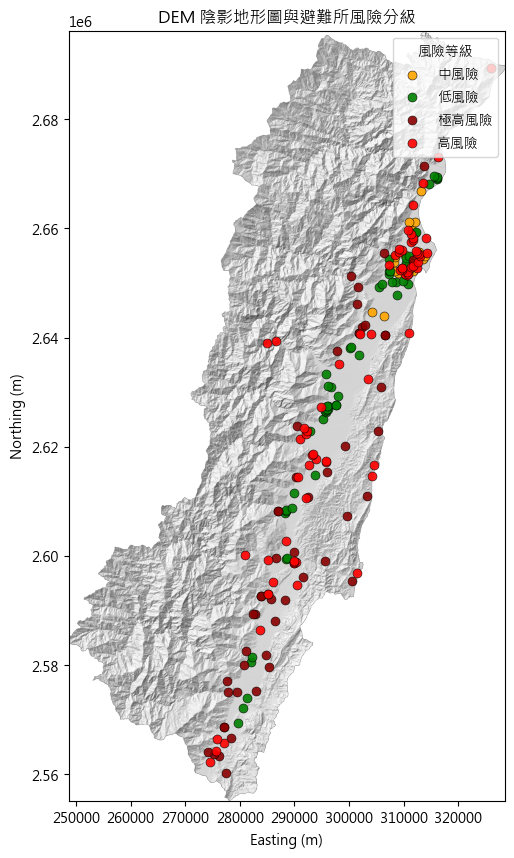

✅ Saved static map to outputs/terrain_risk_map.png


C:\Users\User\AppData\Local\Temp\ipykernel_30548\1160102828.py:132: RuntimeWarning: invalid value encountered in cast
  hs_uint8 = np.uint8(hs_norm * 255)


✅ Saved interactive HTML map to outputs/terrain_risk_map.html


In [38]:
# Cell 8: Create DEM hillshade map with shelter risk overlay
# Outputs:
#   outputs/terrain_risk_map.png
#   outputs/terrain_risk_map.html

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LightSource
import folium
from folium.raster_layers import ImageOverlay
from PIL import Image
from pyproj import Transformer

os.makedirs("outputs", exist_ok=True)

# ---------------------------
# 0) Basic checks
# ---------------------------
if dem is None:
    raise ValueError("❌ dem is None")
if shelters is None:
    raise ValueError("❌ shelters is None")
if 'risk_level' not in shelters.columns:
    raise ValueError("❌ shelters does not have 'risk_level' column")
if 'mean_elevation' not in shelters.columns or 'max_slope' not in shelters.columns:
    raise ValueError("❌ shelters missing mean_elevation or max_slope")

# ---------------------------
# 1) Matplotlib 中文設定
# ---------------------------
mpl.rcParams['font.sans-serif'] = [
    'Microsoft JhengHei',
    'SimHei',
    'Noto Sans CJK TC',
    'Arial Unicode MS'
]
mpl.rcParams['axes.unicode_minus'] = False

# ---------------------------
# 2) 風險顏色設定
# ---------------------------
risk_color_map = {
    '極高風險': 'darkred',
    '高風險': 'red',
    '中風險': 'orange',
    '低風險': 'green'
}

# ---------------------------
# 3) Prepare DEM 2D
# ---------------------------
dem2d = dem.squeeze(drop=True)
elev = dem2d.values.astype("float64")

nodata = dem2d.rio.nodata
if nodata is not None:
    elev[elev == nodata] = np.nan

minx, miny, maxx, maxy = dem2d.rio.bounds()
xres, yres = dem2d.rio.resolution()
xres = abs(xres)
yres = abs(yres)

# ---------------------------
# 4) Create hillshade
# ---------------------------
valid_mask = ~np.isnan(elev)

if np.all(~valid_mask):
    raise ValueError("❌ DEM contains no valid elevation values")

fill_value = np.nanmedian(elev[valid_mask])
elev_filled = np.where(valid_mask, elev, fill_value)

ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elev_filled, vert_exag=1, dx=xres, dy=yres)
hillshade_masked = np.where(valid_mask, hillshade, np.nan)

# ---------------------------
# 5) Prepare shelter points in DEM CRS for static map
# ---------------------------
shelters_map = shelters.to_crs(dem.rio.crs).copy()

# ---------------------------
# 6) Static PNG map with legend
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 10))

ax.imshow(
    hillshade_masked,
    cmap='gray',
    extent=[minx, maxx, miny, maxy],
    origin='upper',
    alpha=0.95
)

for risk_level, group in shelters_map.groupby('risk_level'):
    ax.scatter(
        group.geometry.x,
        group.geometry.y,
        s=42,
        c=risk_color_map.get(risk_level, 'blue'),
        label=risk_level,
        edgecolor='black',
        linewidth=0.4,
        alpha=0.9
    )

ax.set_title("DEM 陰影地形圖與避難所風險分級")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(title="風險等級", loc="upper right", frameon=True)
ax.grid(False)

png_path = "outputs/terrain_risk_map.png"
plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Saved static map to {png_path}")

# ---------------------------
# 7) Create transparent hillshade image for folium HTML map
# ---------------------------
hs = hillshade_masked.copy()
hs_min = np.nanmin(hs)
hs_max = np.nanmax(hs)

# 避免分母為 0
hs_norm = (hs - hs_min) / (hs_max - hs_min + 1e-12)
hs_uint8 = np.uint8(hs_norm * 255)

rgba = np.zeros((hs_uint8.shape[0], hs_uint8.shape[1], 4), dtype=np.uint8)
rgba[..., 0] = hs_uint8
rgba[..., 1] = hs_uint8
rgba[..., 2] = hs_uint8
rgba[..., 3] = np.where(np.isnan(hs), 0, 180)  # 半透明

hillshade_overlay_path = "outputs/hillshade_overlay.png"
Image.fromarray(rgba).save(hillshade_overlay_path)

# ---------------------------
# 8) Convert DEM bounds to WGS84 for folium
# ---------------------------
transformer = Transformer.from_crs(dem.rio.crs, "EPSG:4326", always_xy=True)
lon_min, lat_min = transformer.transform(minx, miny)
lon_max, lat_max = transformer.transform(maxx, maxy)

center_lon = (lon_min + lon_max) / 2
center_lat = (lat_min + lat_max) / 2

# ---------------------------
# 9) Create folium HTML map
# ---------------------------
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=10,
    tiles="CartoDB positron"
)

# Hillshade overlay
ImageOverlay(
    name="DEM Hillshade",
    image=hillshade_overlay_path,
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    opacity=0.7,
    interactive=False,
    cross_origin=False,
    zindex=1
).add_to(m)

# Shelter points in WGS84
shelters_web = shelters.to_crs("EPSG:4326").copy()

for _, row in shelters_web.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color="black",
        weight=1,
        fill=True,
        fill_color=risk_color_map.get(row["risk_level"], "blue"),
        fill_opacity=0.9,
        popup=folium.Popup(
            f"""
            <b>{row.get('name', 'Unknown')}</b><br>
            風險等級：{row.get('risk_level', 'NA')}<br>
            平均高程：{row.get('mean_elevation', np.nan):.2f} m<br>
            最大坡度：{row.get('max_slope', np.nan):.2f}°<br>
            河川距離：{row.get('river_distance_category', 'NA')}
            """,
            max_width=260
        )
    ).add_to(m)

# ---------------------------
# 10) Add folium legend (中文)
# ---------------------------
legend_html = """
<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 180px; height: 185px; 
    background-color: white; 
    border: 2px solid grey; 
    z-index: 9999; 
    font-size: 14px;
    padding: 10px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    border-radius: 6px;
">
<b>地圖圖例</b><br>
<div style="margin-top: 8px;">
    <span style="display:inline-block;width:12px;height:12px;background:gray;border:1px solid black;margin-right:6px;"></span>DEM 陰影地形
</div>
<div style="margin-top: 4px;">
    <span style="display:inline-block;width:12px;height:12px;background:darkred;border:1px solid black;margin-right:6px;"></span>極高風險
</div>
<div style="margin-top: 4px;">
    <span style="display:inline-block;width:12px;height:12px;background:red;border:1px solid black;margin-right:6px;"></span>高風險
</div>
<div style="margin-top: 4px;">
    <span style="display:inline-block;width:12px;height:12px;background:orange;border:1px solid black;margin-right:6px;"></span>中風險
</div>
<div style="margin-top: 4px;">
    <span style="display:inline-block;width:12px;height:12px;background:green;border:1px solid black;margin-right:6px;"></span>低風險
</div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m)

html_path = "outputs/terrain_risk_map.html"
m.save(html_path)

print(f"✅ Saved interactive HTML map to {html_path}")

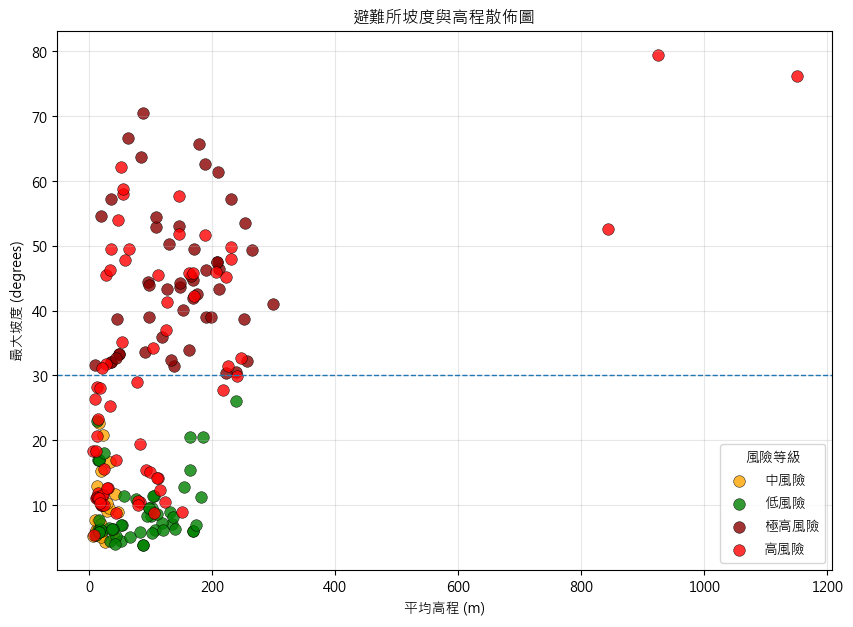

✅ Saved scatter plot to outputs/high_risk_shelters_scatter.png

=== High-Risk Shelters Summary ===
   shelter_id          name risk_level  mean_elevation  max_slope  \
0      SH0046          和平國小        高風險       27.502351  45.473255   
1      SH1306      豐南社區活動中心       極高風險      299.459149  41.046371   
2      SH1332           玉寶宮        高風險      240.630908  29.891893   
3      SH1342      永豐社區活動中心       極高風險      257.456815  32.286249   
4      SH1350      富里老人文康中心       極高風險      238.324347  30.526334   
5      SH1353      石平社區活動中心       極高風險      265.358109  49.298894   
6      SH1355       富里鄉公所2樓        高風險      246.178914  32.616479   
7      SH1379      石牌社區活動中心        高風險      217.740581  27.666911   
8      SH1386      明里社區活動中心        高風險      222.762285  45.127978   
9      SH1389         羅山縱管處       極高風險      222.573043  30.428217   
10     SH1422          古風國小       極高風險      211.241186  43.365711   
11     SH1426      崙天社區活動中心       極高風險      211.363013  46.451935   
12  

In [ ]:
# Cell 9: All high-risk shelters scatter plot
# Output:
#   outputs/high_risk_shelters_scatter.png

import os
import matplotlib.pyplot as plt
import matplotlib as mpl

os.makedirs("outputs", exist_ok=True)

# --- 修正中文顯示 ---
mpl.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Noto Sans CJK TC', 'Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False

if shelters is None:
    raise ValueError("❌ shelters is None")
if 'risk_level' not in shelters.columns:
    raise ValueError("❌ shelters does not have 'risk_level'")
if 'mean_elevation' not in shelters.columns or 'max_slope' not in shelters.columns:
    raise ValueError("❌ shelters missing mean_elevation or max_slope")

# 若前面沒有定義，這裡補一份
risk_color_map = {
    '極高風險': 'darkred',
    '高風險': 'red',
    '中風險': 'orange',
    '低風險': 'green'
}

# 只取高風險 / 極高風險
high_risk = shelters.copy()

if len(high_risk) == 0:
    raise ValueError("❌ No high-risk shelters found")

plt.figure(figsize=(10, 7))

for risk_level, group in high_risk.groupby('risk_level'):
    plt.scatter(
        group['mean_elevation'],
        group['max_slope'],
        s=70,
        label=risk_level,
        c=risk_color_map.get(risk_level, 'blue'),
        edgecolor='black',
        linewidth=0.4,
        alpha=0.8
    )

plt.axhline(30, linestyle='--', linewidth=1)
plt.xlabel("平均高程 (m)")
plt.ylabel("最大坡度 (degrees)")
plt.title("避難所坡度與高程散佈圖")
plt.legend(title="風險等級")
plt.grid(True, alpha=0.3)

scatter_path = "outputs/high_risk_shelters_scatter.png"
plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Saved scatter plot to {scatter_path}")
print("\n=== High-Risk Shelters Summary ===")
print(high_risk[['shelter_id', 'name', 'risk_level', 'mean_elevation', 'max_slope', 'river_distance_category']].head(20))
print(f"\n總筆數：{len(high_risk)}")